## Load Data
Pada eksperimen share vs non-share parameter, kami menjalankan notebook ini di Collab agar bisa memanfaatkan GPU yang ada. Dataset di-download dan di ekstrak di lokal. Karena keterbatasan push data besar ke github, maka dataset tidak di push ke repository dan dapat diakses melalui kaggle https://www.kaggle.com/datasets/puneet6060/intel-image-classification. 

In [3]:
!pip install tensorflow scikit-learn matplotlib seaborn kaggle


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

import gdown
import zipfile

url = "https://drive.google.com/file/d/19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM/view?usp=drive_link"

gdown.download(url, "../../data/cnn_data/dataset.zip", quiet=False)


with zipfile.ZipFile("../../data/cnn_data/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("../../data/cnn_data")

train_dir = "../../data/cnn_data/seg_train/seg_train"
test_dir = "../../data/cnn_data/seg_test/seg_test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("Load Data Training:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int' 
)

print("\nLoad Data Testing:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False 
)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
print(f"\nJumlah label test: {y_true.shape[0]}")

Downloading...
From (original): https://drive.google.com/uc?id=19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM
From (redirected): https://drive.google.com/uc?id=19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM&confirm=t&uuid=b427ebbf-57bb-4975-8b21-798306b82e05
To: c:\Users\diyah\Tubes2_IF3270_Kelompok9\src\cnn\dataset.zip
100%|██████████| 363M/363M [00:35<00:00, 10.3MB/s] 


Load Data Training:
Found 14034 files belonging to 6 classes.

Load Data Testing:
Found 3000 files belonging to 6 classes.

Jumlah label test: 3000


## Train and Evaluate

In [ ]:
def train_and_evaluate(model_name, model, epochs=10):
    print(f"\n" + "="*40)
    print(f" MULAI TRAINING: {model_name}")
    print("="*40)

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_ds, validation_data=test_ds, epochs=epochs)

    # hitung F1-Score
    print("\nMenghitung Macro F1-Score...")
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"MACRO F1-SCORE: {macro_f1:.4f}")

    # simpan Bobot
    save_path = f"{model_name}.weights.h5"
    model.save_weights(save_path)
    print(f"Bobot disimpan di: {save_path}")

    # grafik loss & accuracy
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # accuracy
    axes[0].plot(history.history['accuracy'], label='Train Acc')
    axes[0].plot(history.history['val_accuracy'], label='Val Acc')
    axes[0].set_title(f'Accuracy - {model_name}')
    axes[0].legend()

    # loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss - {model_name}')
    axes[1].legend()

    plt.show()

    return history, macro_f1

# menyimpan skor akhir untuk perbandingan
hasil_eksperimen = {}

## Model Non-Shared (Locally Connected)
Berdasarkan hasil pelatihan model dengan 16 arsitektur di bagian 3, diperoleh bahwa model terbaik adalah model Kombinasi 12 dengan arsitektur 3 Layer, Filter 32->64->128, Kernel 5x5, Avg Pooling. Namun setelah dilakukan rekonstruksi dengan asitektur yang sama dan menggunakan locally connected, waktu yang dibutuhkan untuk training sangat-sangat lama, sudah satu jam dan 1 epoch belum selesai. Oleh karena itu, pada eksperimen ini digunakan kombinasi arsitektur yang lebih sederhana agar waktu yang dibutuhkan untuk training tidak terlalu lama. Konfigurasi yang digunakan pada model non-shared dan shared dibuat sama agar perbandingan yang dilakukan adil dan objektif.
 

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras

model_12_non_shared = keras.Sequential([
    keras.layers.InputLayer(input_shape=(150, 150, 3)),

    keras.layers.AveragePooling2D(pool_size=(4, 4), strides=4),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(4, (3, 3), activation='relu'), # Filter 4
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.LocallyConnected2D(8, (3, 3), activation='relu'), # Filter 8
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

model_12_non_shared.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 average_pooling2d (Average  (None, 37, 37, 3)         0         
 Pooling2D)                                                      
                                                                 
 zero_padding2d (ZeroPaddin  (None, 41, 41, 3)         0         
 g2D)                                                            
                                                                 
 locally_connected2d (Local  (None, 39, 39, 4)         170352    
 lyConnected2D)                                                  
                                                                 
 average_pooling2d_1 (Avera  (None, 19, 19, 4)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_1 (ZeroPadd  (None, 23, 23, 4)         0


 MULAI TRAINING: Non_Shared_Kombinasi_12
Epoch 1/3
439/439 [==============================] - 84s 114ms/step - loss: 0.8258 - accuracy: 0.6865 - val_loss: 1.0156 - val_accuracy: 0.6080
Epoch 2/3
439/439 [==============================] - 28s 63ms/step - loss: 0.7886 - accuracy: 0.6999 - val_loss: 1.0107 - val_accuracy: 0.6213
Epoch 3/3
439/439 [==============================] - 27s 61ms/step - loss: 0.7483 - accuracy: 0.7173 - val_loss: 0.9362 - val_accuracy: 0.6690

Menghitung Macro F1-Score...
94/94 [==============================] - 24s 51ms/step
MACRO F1-SCORE: 0.6714
Bobot disimpan di: Non_Shared_Kombinasi_12.weights.h5


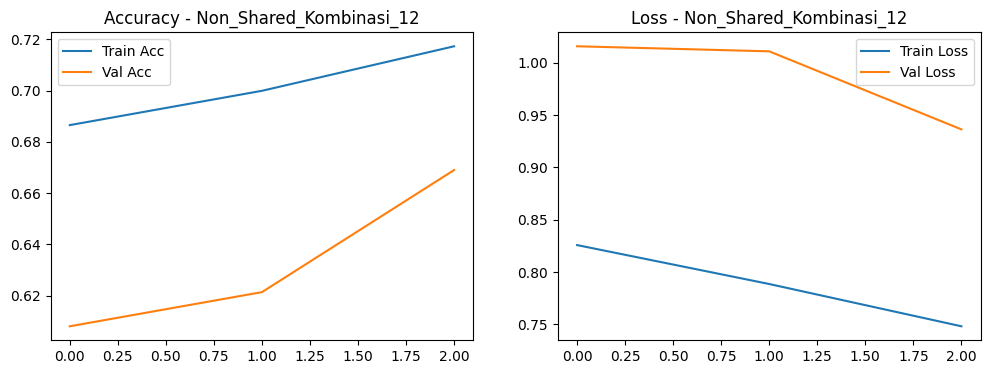

In [8]:
_, f1_12_ns = train_and_evaluate("Non_Shared_Kombinasi_12", model_12_non_shared, epochs=3)
hasil_eksperimen["Non_Shared_Kombinasi_12"] = f1_12_ns

## Model Shared Parameter

In [5]:
model_12_shared = keras.Sequential([
    keras.layers.InputLayer(input_shape=(150, 150, 3)),

    keras.layers.AveragePooling2D(pool_size=(4, 4), strides=4),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.Conv2D(4, (3, 3), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.ZeroPadding2D(padding=(2, 2)),
    keras.layers.Conv2D(8, (3, 3), activation='relu'),
    keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),

    keras.layers.Flatten(),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(6, activation='softmax')
])

model_12_shared.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 average_pooling2d_3 (Avera  (None, 37, 37, 3)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_2 (ZeroPadd  (None, 41, 41, 3)         0         
 ing2D)                                                          
                                                                 
 conv2d (Conv2D)             (None, 39, 39, 4)         112       
                                                                 
 average_pooling2d_4 (Avera  (None, 19, 19, 4)         0         
 gePooling2D)                                                    
                                                                 
 zero_padding2d_3 (ZeroPadd  (None, 23, 23, 4)         0         
 ing2D)                                               


 MULAI TRAINING: Shared_Kombinasi_12
Epoch 1/3
439/439 [==============================] - 80s 103ms/step - loss: 0.7232 - accuracy: 0.7269 - val_loss: 0.9349 - val_accuracy: 0.6577
Epoch 2/3
439/439 [==============================] - 26s 59ms/step - loss: 0.6837 - accuracy: 0.7423 - val_loss: 0.9380 - val_accuracy: 0.6700
Epoch 3/3
439/439 [==============================] - 27s 61ms/step - loss: 0.6597 - accuracy: 0.7535 - val_loss: 0.9392 - val_accuracy: 0.6763

Menghitung Macro F1-Score...
94/94 [==============================] - 23s 39ms/step
MACRO F1-SCORE: 0.6772
Bobot disimpan di: Shared_Kombinasi_12.weights.h5


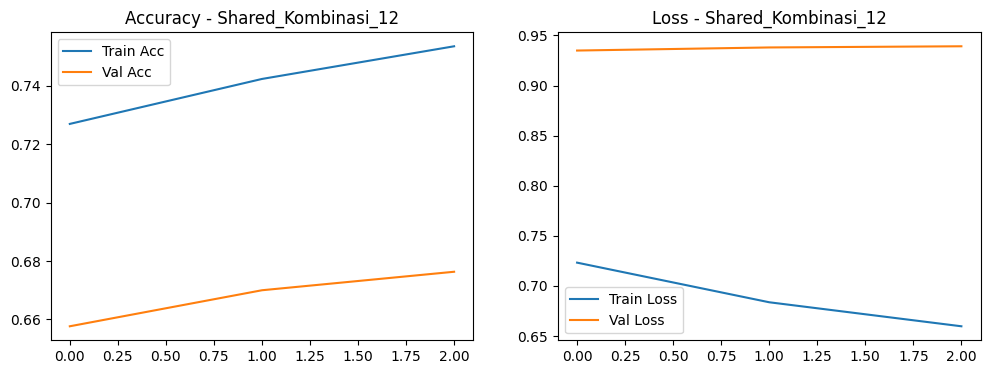

In [9]:
_, f1_12_s = train_and_evaluate("Shared_Kombinasi_12", model_12_non_shared, epochs=3)
hasil_eksperimen["Shared_Kombinasi_12"] = f1_12_s

## Analisis
Pada eksperimen Shared VS Non-Shared, terjadi bottleneck yang menyebabkan proses training tidak mengalami progress sama sekali tetap saat menggunakan LocallyConnected dengan arsitektur kombinasi 12. Setelah di training selama satu jam, epoch 1 tidak menghasilkan progress apapun. Hal ini dikarenakan jumlah trainable parameternya sangat besar dan berukuran lebih dari 2GB. Oleh karena itu, agar tetap bisa membandingkan performa antara shared dan non-shared, maka dibuatlah arsitektur yang lebih sederhana dengan catatan perbandingan dilakukan *apple to apple* menggunakan arsitektur yang sama.

Berdasarkan hasil eksperimen, terlihat bahwa Macro F-1 score untuk shared parameter (0.6772) lebih tinggi dibandingkan untuk non-shared (0.6714) meskipun jumlah trainable parameternya jauh lebih sedikit. Hal ini membuktikan hipotesis bahwa performa non-shared parameter **sangat buruk** dan tidak efektif. Oleh karena itu, arsitektur non-shared parameter sudah sangat jarang digunakan dalam industri. Dengan arsitektur serupa namun menggunakan shared parameter terbukti menghasilkan nilai Macro F-1 score yang lebih baik dan proses training yang jauh lebih cepat.